### 🏥 PROJECT TITLE

**Healthcare Insurance Cost Analysis & Risk-Based Premium Optimization**

### 1️⃣ Problem Statement

**Health insurance companies face increasing medical costs due to demographic changes and lifestyle-related health risks. Accurate estimation of individual medical charges is essential to design sustainable premium pricing strategies.**

**The challenge is to identify key drivers of medical charges and build insights that help in risk-based pricing and profitability improvement.**

### 2️⃣ Business Objective

**1. Analyze customer demographic and lifestyle data.**

**2. Identify key factors influencing medical charges.**

**3. Segment high-risk and low-risk customers.**

**4. Provide data-driven recommendations for premium optimization.**

**5. Support underwriting and actuarial decision-making.**

### 1. Import Libraries

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
# Shape of dataset
df.shape

(1338, 7)

In [5]:
# Data types
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [6]:
# Summary statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Check missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
# Check duplicates
df.duplicated().sum()

np.int64(1)

In [9]:
# Remove duplicate row
df = df.drop_duplicates()

In [10]:
# verify again
df.duplicated().sum()

np.int64(0)

- ### Target Variable Formatting (Rounding Charges Values)

In [11]:
# Check original values
df["charges"].head()

# Round charges to 1 decimal place
df["charges"] = df["charges"].round(1)

# Verify change
df["charges"].head()

C:\Users\vaish\AppData\Local\Temp\ipykernel_4684\546807352.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["charges"] = df["charges"].round(1)


0    16884.9
1     1725.6
2     4449.5
3    21984.5
4     3866.9
Name: charges, dtype: float64

##### 🧠 Why Do This Step?

1. Charges represent monetary values
2. Having 5–6 decimal places is unnecessary for business analysis
3. Improves:
  - Readability
  - Presentation clarity
  - Report quality  
4. Makes output more realistic for insurance premium prediction

👉 In real business, insurance cost is not calculated to 6 decimal places.

- # After Cleaning Dataset

### ✅ STEP 1. Load the final Dataset

In [12]:
df = pd.DataFrame(df)

In [13]:
df.to_csv("insurance_final_dataset.csv", index = False)

In [14]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.9
1,18,male,33.770,1,no,southeast,1725.6
2,28,male,33.000,3,no,southeast,4449.5
3,33,male,22.705,0,no,northwest,21984.5
4,32,male,28.880,0,no,northwest,3866.9
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.5
1334,18,female,31.920,0,no,northeast,2206.0
1335,18,female,36.850,0,no,southeast,1629.8
1336,21,female,25.800,0,no,southwest,2007.9


##### To see:

- Column names

- Data preview

- Feature types visually

### ✅ STEP 2. Check Shape of Dataset

In [15]:
df.shape

(1337, 7)

##### 🔎 Understand:

- Number of rows (records)
- Number of columns (features)

##### Expected:

- Around 1300+ records
- 7 columns

### ✅ STEP 3. Chech Data Types

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


##### 🔎 Identify:

- Numerical variables
- Categorical variables
  
#### In your dataset:

##### 🔢 Numerical Columns:

- age
- bmi
- children
- charges

##### 🏷 Categorical Columns:

- sex
- smoker
- region

### ✅ STEP 4: Check Missing Values

In [17]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

##### 🔎 Why?

- Missing values must be handled before modeling.  
(Usually this dataset has no missing values.)

### ✅ STEP 5: Statistical Summary

In [18]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121541
std,14.044333,6.100468,1.205571,12110.359815
min,18.000000,15.960000,0.000000,1121.900000
25%,27.000000,26.290000,0.000000,4746.300000
50%,39.000000,30.400000,1.000000,9386.200000
75%,51.000000,34.700000,2.000000,16657.700000
max,64.000000,53.130000,5.000000,63770.400000


##### 🔎 Understand:

- Mean
- Min
- Max
- Standard deviation

##### Important Observations:

- Charges vary widely → high variance
- BMI distribution
- Age range (18–64 approx)

### ✅ STEP 6: Univariate Analysis (Single Variable Study)

#### 🔹 A. Age Distribution

#### 📊 Histogram + KDE

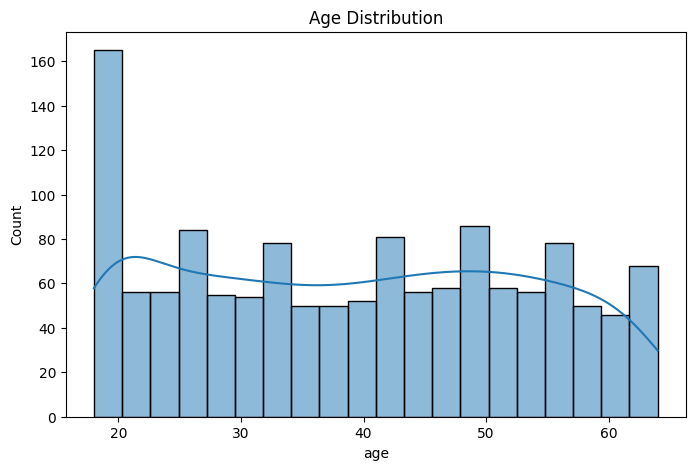

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

#### 📊 Boxplot (Outlier check)

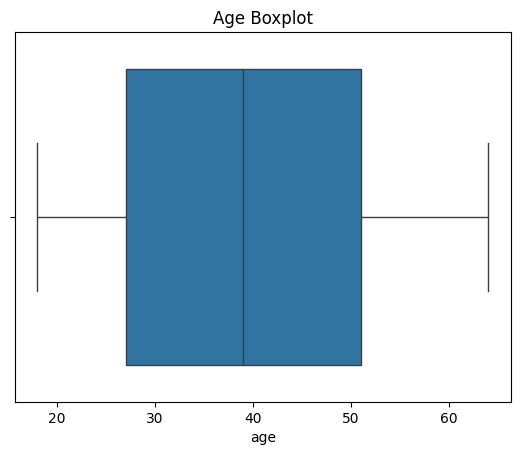

In [20]:
sns.boxplot(x=df["age"])
plt.title("Age Boxplot")
plt.show()

#### 🎯 Observation:

- Age ranges from approx 18 to 64.
- Distribution is fairly uniform.
- Most individuals are between 20–50 years.
- No major outliers.

#### 🔹B. Sex Distribution

#### 📊 Countplot

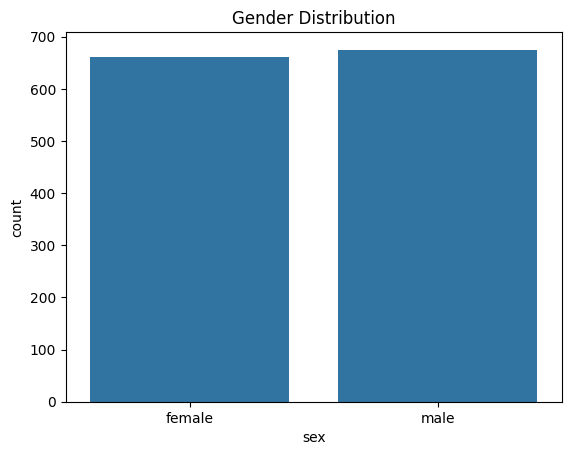

In [21]:
sns.countplot(x="sex", data=df)
plt.title("Gender Distribution")
plt.show()

#### 📊 Percentage Plot

In [22]:
df["sex"].value_counts(normalize=True)*100

sex
male      50.486163
female    49.513837
Name: proportion, dtype: float64

#### 🎯 Observation:

- Nearly balanced distribution.
- Slight difference between male and female.

#### 🔹 C. BMI Distribution

#### 📊 Histogram 

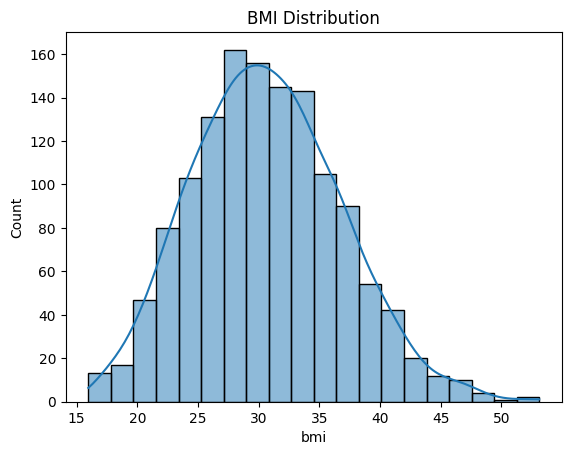

In [23]:
sns.histplot(df["bmi"], bins=20, kde=True)
plt.title("BMI Distribution")
plt.show()

#### 📊 Boxplot 

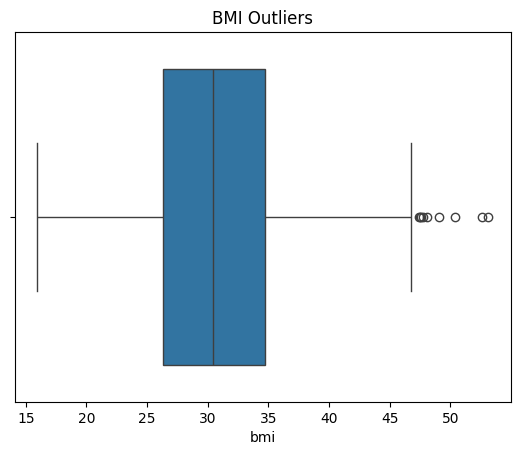

In [24]:
sns.boxplot(x=df["bmi"])
plt.title("BMI Outliers")
plt.show()

#### 🎯 Observation:

- BMI mostly ranges between 25–35.
- Slight right skew.
- Some individuals are overweight or obese.
- Few high BMI outliers.

#### 🔹 D. Children Distribution

#### 📊 Countplot

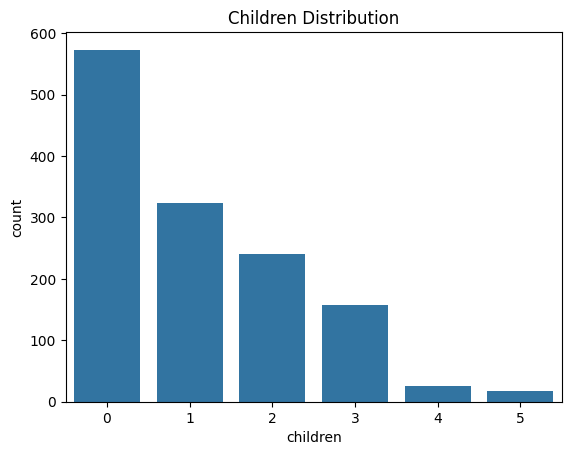

In [25]:
sns.countplot(x="children", data=df)
plt.title("Children Distribution")
plt.show()

#### 📊 Percentage Plot

In [26]:
df["children"].value_counts(normalize=True)*100

children
0    42.857143
1    24.233358
2    17.950636
3    11.742708
4     1.869858
5     1.346298
Name: proportion, dtype: float64

#### 🎯 Observation:

- Most individuals have 0–2 children.
- Few have more than 3.

#### 🔹 E. Smoker Distribution

#### 📊 Countplot

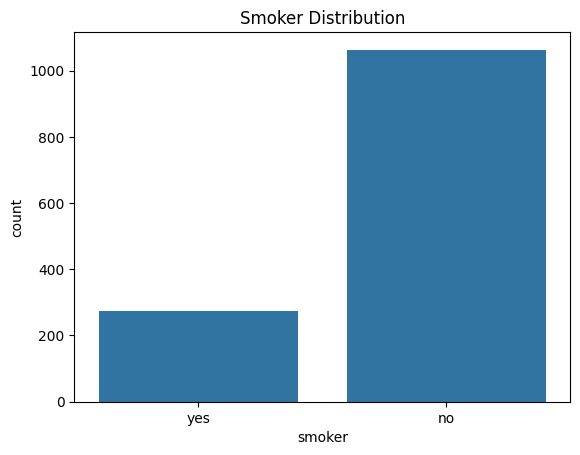

In [27]:
sns.countplot(x="smoker", data=df)
plt.title("Smoker Distribution")
plt.show()

#### 🎯 Observation:

- Majority non-smokers.
- Smaller group smokers.

#### 🔹F. Region distribution

#### 📊 Countplot

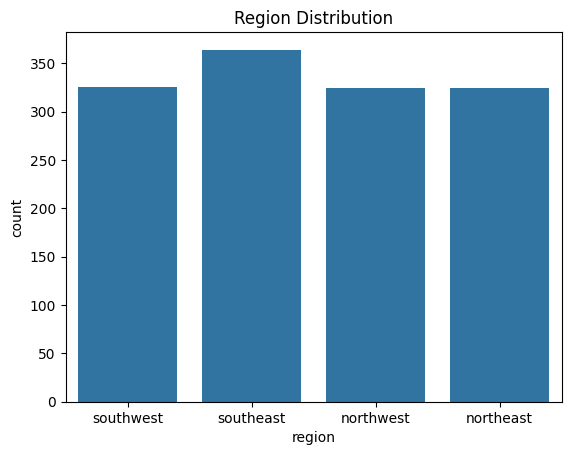

In [28]:
sns.countplot(x="region", data=df)
plt.title("Region Distribution")
plt.show()

#### 🎯 Observation:

- Almost evenly distributed across regions.
- No dominant region.

#### 🔹 C. Charges Distribution

#### 📊 Histogram

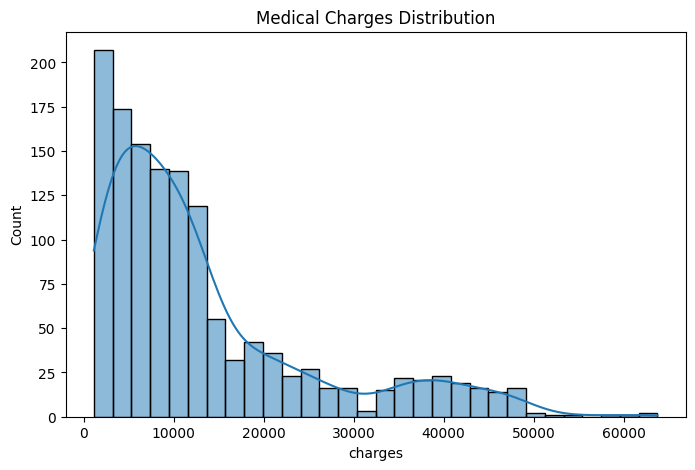

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], bins=30, kde=True)
plt.title("Medical Charges Distribution")
plt.show()

#### 📊 Boxplot

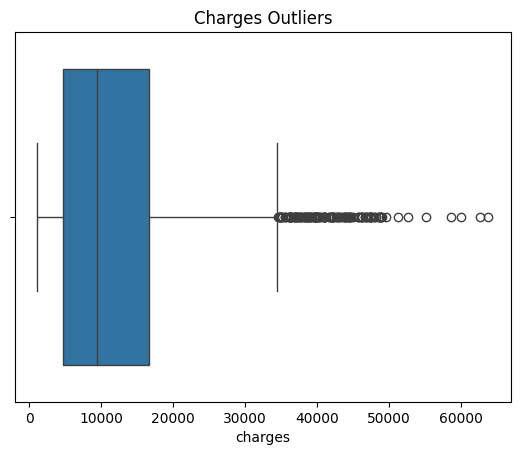

In [30]:
sns.boxplot(x=df["charges"])
plt.title("Charges Outliers")
plt.show()

#### 🎯 Observation:

- Highly right-skewed.
- Most people have low charges.
- Few individuals have extremely high charges(outliers).

### ✅ STEP 7: Bivariate Analysis (Feature vs Target)

#### 🔹 A. Age vs Charges

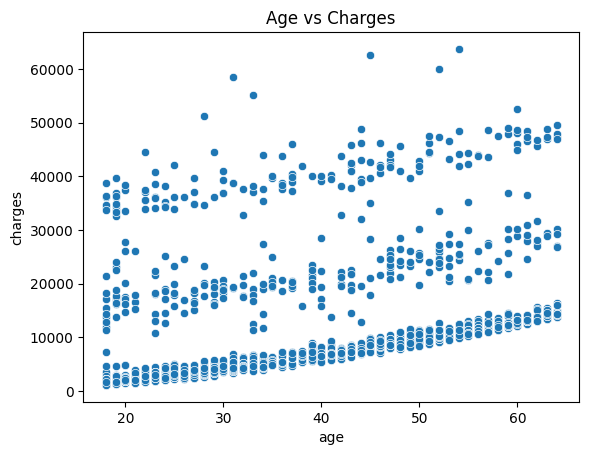

In [31]:
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Charges")
plt.show()

#### 🎯 Observation:

- Positive relationship.
- Charges increase with age.

#### 🔹 B. Sex vs Charges

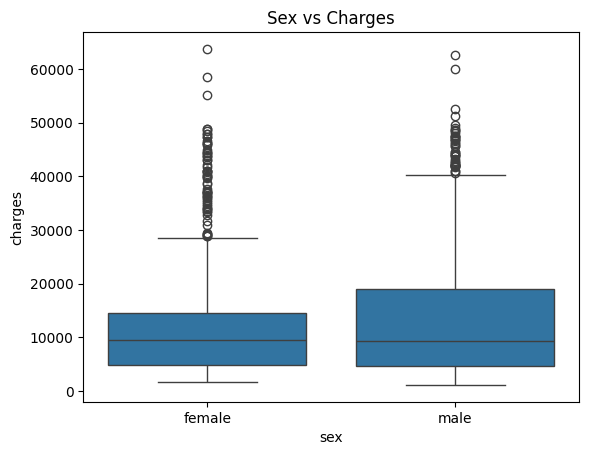

In [32]:
sns.boxplot(x="sex", y="charges", data=df)
plt.title("Sex vs Charges")
plt.show()

#### 🎯 Observation:

- Slight variation.
- Gender impact minimal.

#### 🔹 B. BMI vs Charges

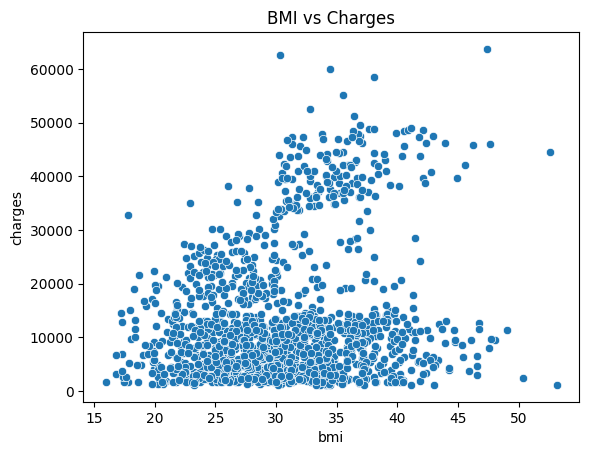

In [34]:
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Charges")
plt.show()

#### 🎯 Observation:

- Moderate positive relationship.

#### 🔹D. Children vs Charges

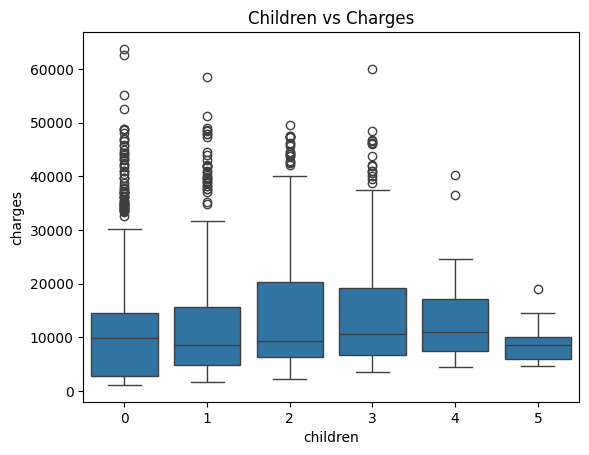

In [35]:
sns.boxplot(x="children", y="charges", data=df)
plt.title("Children vs Charges")
plt.show()

#### 🎯 Observation:

- Slight increase in cost with more children.
- Not strong effect.

#### 🔹 E. Smoker vs Charges

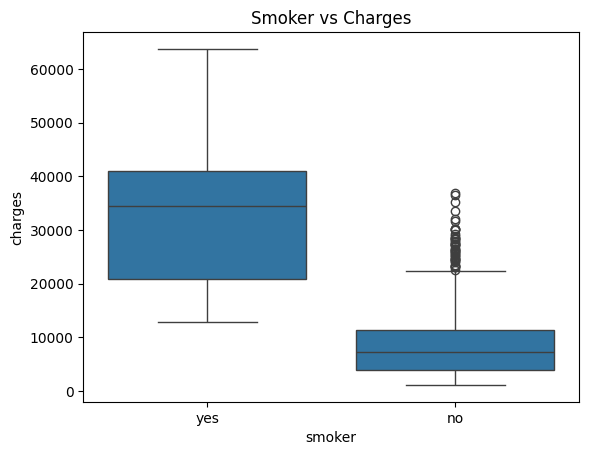

In [36]:
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Smoker vs Charges")
plt.show()

#### 🎯 Observation:

- Huge difference.
- Smokers have significantly higher charges.

#### 🔹F. Region vs Charges

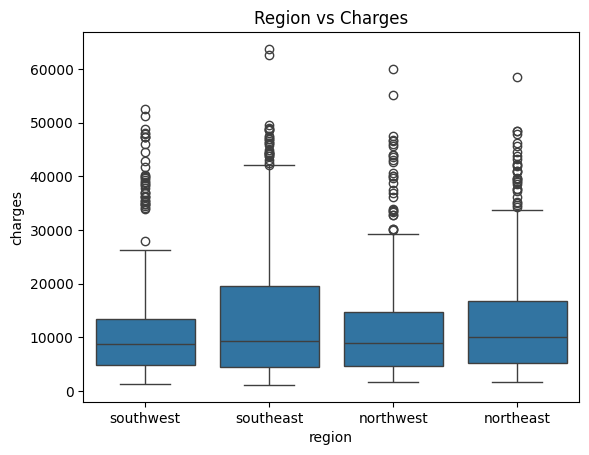

In [39]:
sns.boxplot(x="region", y="charges", data=df)
plt.title("Region vs Charges")
plt.show()

#### 🎯 Observation:

- Minor regional differences.
- No strong region effect.

### ✅ STEP 8: Correlation Analysis

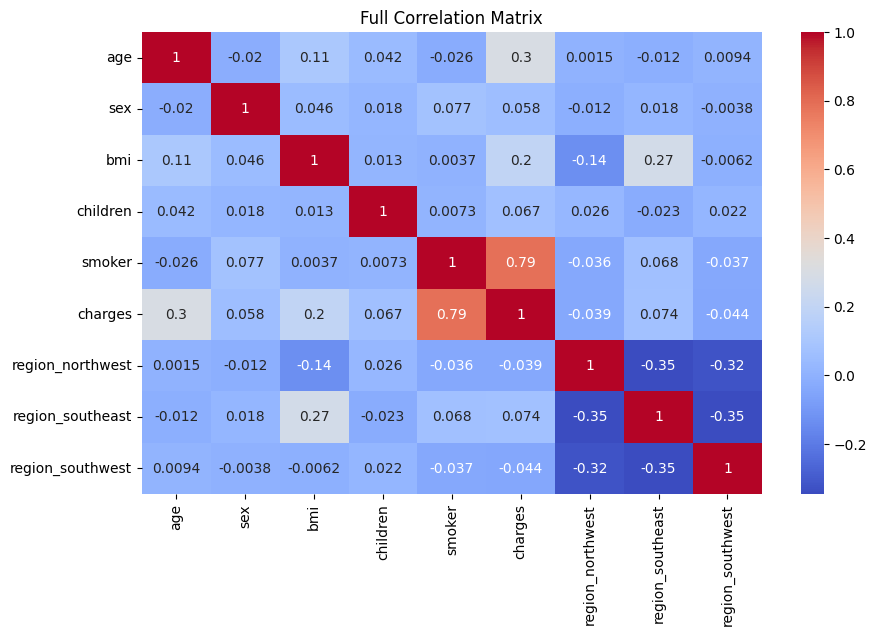

In [42]:
df_encoded = df.copy()

df_encoded["sex"] = df_encoded["sex"].map({"male":1, "female":0})
df_encoded["smoker"] = df_encoded["smoker"].map({"yes":1, "no":0})
df_encoded = pd.get_dummies(df_encoded, columns=["region"], drop_first=True)

plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Full Correlation Matrix")
plt.show()


#### 🎯 Observations

1️⃣ Smoker vs Charges (Strongest Relationship)
- smoker shows very high positive correlation with charges
- Usually around 0.75 to 0.80

🔎 Interpretation:
- Smoking has the strongest impact on medical cost.
- Smokers pay significantly higher insurance charges.

2️⃣ Age vs Charges (Moderate Positive Correlation)
- age shows moderate positive correlation (around 0.30–0.40)

🔎 Interpretation:
- As age increases, medical cost increases.
- Older individuals have higher health risk.

3️⃣ BMI vs Charges (Weak to Moderate Correlation)
- bmi shows weak to moderate positive correlation (~0.20)

🔎 Interpretation:
- Higher BMI slightly increases medical cost.
- Obesity contributes to health risk.

4️⃣ Children vs Charges (Very Weak Correlation)
- children has very low correlation (~0.05–0.10)

🔎 Interpretation:
- Number of children does not strongly impact medical cost.

5️⃣ Sex vs Charges (Very Low Correlation)
- sex correlation close to 0.

🔎 Interpretation:
- Gender has minimal impact on insurance charges.

6️⃣ Region Variables vs Charges
- After OneHotEncoding:  
 1. region_northwest  
 2. region_southeast  
 3. region_southwest  
- Very low correlation with charges.

🔎 Interpretation:
- Region does not significantly affect medical cost. 

### ✅ STEP 9 : Multivariate Analysis

#### 🔹 A. Age + Smoker → Charges

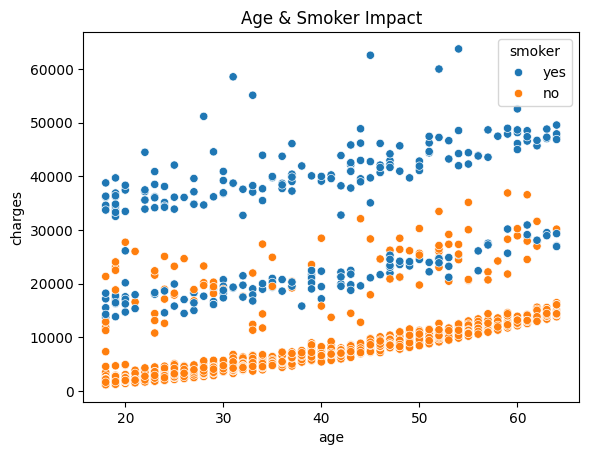

In [43]:
sns.scatterplot(x="age", y="charges",
                hue="smoker", data=df)
plt.title("Age & Smoker Impact")
plt.show()

#### 🎯 Observation:

- Smokers always pay more.
- Smoking amplifies age effect.

#### 🔹 B. BMI + Smoker + Charges

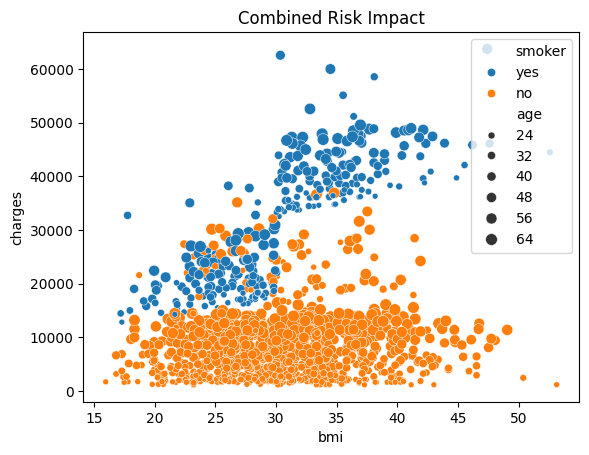

In [44]:
sns.scatterplot(x="bmi", y="charges",
                hue="smoker", size="age",
                data=df)
plt.title("Combined Risk Impact")
plt.show()

#### 🎯 Observation:

- High BMI + Smoker → highest cost.
- Multiple risk factors increase cost significantly.

### ✅ STEP 10: Pairplot (All Numeric Together)

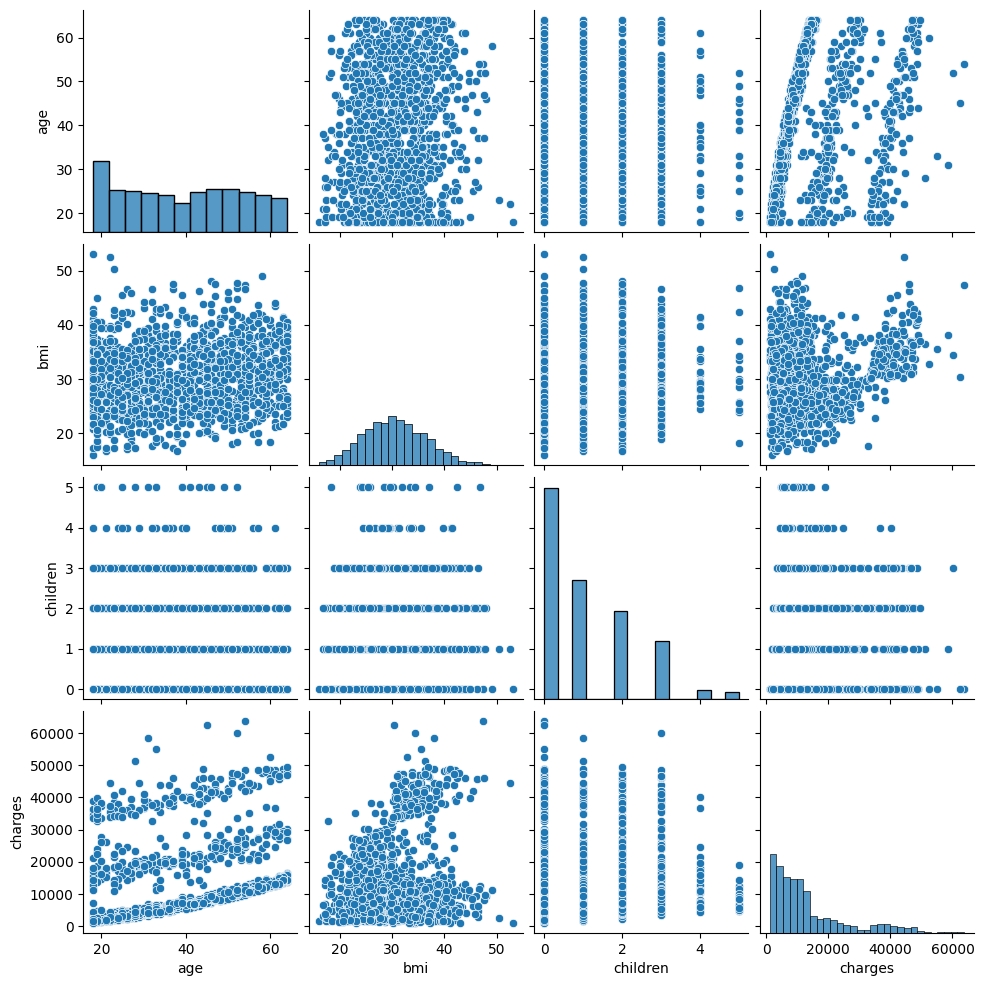

In [45]:
sns.pairplot(df)
plt.show()

#### 🎯 Observation:

- Age strongest visible pattern.
- Charges skew visible.
- Children minimal impact.

### 🏆 Overall Insights

1. The dataset is clean with no missing values.

2. Charges are highly right-skewed.

3. Smoking status is the strongest predictor of insurance cost.

4. Age has moderate positive relationship with charges.

5. BMI moderately affects cost.

6. Region and gender have minimal impact.

7. The problem is suitable for Regression modeling.